In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log
/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_structured.csv
/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_templates.csv


In [2]:
import pandas as pd

In [3]:
data=pd.read_csv("/kaggle/input/datasets/ggsri123/linux-logs/Linux_2k.log_structured.csv")
data

,LineId,Month,Date,Time,Level,Component,PID,Content,EventId,EventTemplate
0,1,Jun,14,15:16:01,combo,sshd(pam_unix),19939.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
1,2,Jun,14,15:16:02,combo,sshd(pam_unix),19937.0,check pass; user unknown,E27,check pass; user unknown
2,3,Jun,14,15:16:02,combo,sshd(pam_unix),19937.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
3,4,Jun,15,02:04:59,combo,sshd(pam_unix),20882.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
4,5,Jun,15,02:04:59,combo,sshd(pam_unix),20884.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...,...,...,...,...,...
1995,1996,Jul,27,14:41:59,combo,kernel,NaN,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,E83,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,1997,Jul,27,14:42:00,combo,kernel,NaN,isapnp: Scanning for PnP cards...,E60,isapnp: Scanning for PnP cards...
1997,1998,Jul,27,14:42:00,combo,kernel,NaN,isapnp: No Plug & Play device found,E59,isapnp: No Plug & Play device found
1998,1999,Jul,27,14:42:00,combo,kernel,NaN,Real Time Clock Driver v1.12,E87,Real Time Clock Driver v<*>.<*>


In [4]:
data.shape

(2000, 10)

In [5]:
data["Level"].value_counts()

Level
combo    2000
Name: count, dtype: int64

In [6]:
data=data.drop(["LineId","Month","Date","Level","Time"],axis=1)
data.shape

(2000, 5)

In [7]:
data

,Component,PID,Content,EventId,EventTemplate
0,sshd(pam_unix),19939.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
1,sshd(pam_unix),19937.0,check pass; user unknown,E27,check pass; user unknown
2,sshd(pam_unix),19937.0,authentication failure; logname= uid=0 euid=0 ...,E16,authentication failure; logname= uid=0 euid=0 ...
3,sshd(pam_unix),20882.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
4,sshd(pam_unix),20884.0,authentication failure; logname= uid=0 euid=0 ...,E18,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,kernel,NaN,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,E83,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,kernel,NaN,isapnp: Scanning for PnP cards...,E60,isapnp: Scanning for PnP cards...
1997,kernel,NaN,isapnp: No Plug & Play device found,E59,isapnp: No Plug & Play device found
1998,kernel,NaN,Real Time Clock Driver v1.12,E87,Real Time Clock Driver v<*>.<*>


In [8]:
data["Component"].value_counts()

Component
ftpd               916
sshd(pam_unix)     677
su(pam_unix)       172
kernel              76
klogind             46
logrotate           43
named               16
cups                12
udev                 8
syslogd 1.4.1        7
gdm(pam_unix)        2
xinetd               2
login(pam_unix)      2
gpm                  2
bluetooth            2
network              2
syslog               2
snmpd                1
gdm-binary           1
-- root              1
irqbalance           1
portmap              1
nfslock              1
rpc.statd            1
rpcidmapd            1
random               1
sysctl               1
rc                   1
hcid                 1
sdpd                 1
Name: count, dtype: int64

In [9]:
data["PID"].value_counts()

PID
2306.0     16
12753.0     3
2803.0      3
19085.0     3
12754.0     3
           ..
6601.0      1
6600.0      1
6598.0      1
6597.0      1
7704.0      1
Name: count, Length: 1550, dtype: int64

In [10]:
data["EventId"].value_counts()

EventId
E29     909
E18     351
E101    123
E102    122
E27     117
       ... 
E83       1
E60       1
E59       1
E87       1
E66       1
Name: count, Length: 118, dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder

comp_label=LabelEncoder()
data["Component"]=comp_label.fit_transform(data["Component"])

pid_label=LabelEncoder()
data["PID"]=comp_label.fit_transform(data["PID"])

pid_label=LabelEncoder()
data["EventId"]=comp_label.fit_transform(data["EventId"])

In [12]:
data

,Component,PID,Content,EventId,EventTemplate
0,23,690,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
1,23,689,check pass; user unknown,38,check pass; user unknown
2,23,689,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
3,23,693,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
4,23,695,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,9,1550,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,100,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,9,1550,isapnp: Scanning for PnP cards...,75,isapnp: Scanning for PnP cards...
1997,9,1550,isapnp: No Plug & Play device found,73,isapnp: No Plug & Play device found
1998,9,1550,Real Time Clock Driver v1.12,104,Real Time Clock Driver v<*>.<*>


In [13]:
data["Content"].dtype

dtype('O')

In [14]:
data["EventTemplate"].dtype

dtype('O')

In [15]:
data.isna().sum()

Component        0
PID              0
Content          0
EventId          0
EventTemplate    0
dtype: int64

In [16]:
# from sentence_transformers import SentenceTransformer

# model=SentenceTransformer("all-miniLM-L6-v2")

In [17]:
# cont_embed=model.encode(data["Content"].to_list(),show_progress_bar=True)
# event_embed=model.encode(data["EventTemplate"].to_list(),show_progress_bar=True)

In [18]:
import numpy as np

In [19]:
# cont_embed=np.array(cont_embed,np.float32)
# event_embed=np.array(event_embed,np.float32)

In [20]:
# data["Content"]=cont_embed
# data["EventTemplate"]=event_embed

In [21]:
from sklearn.model_selection import train_test_split

x = data[['Component', 'PID', 'Content','EventId']]
y = data['EventTemplate']

from sklearn.preprocessing import LabelEncoder

scaler=LabelEncoder()
y=scaler.fit_transform(data['EventTemplate'])
x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(), 'Content')
    ],
    remainder='passthrough'
)

x_train = preprocessor.fit_transform(x_train_raw)
x_test = preprocessor.transform(x_test_raw)

In [23]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24104 stored elements and shape (1600, 601)>

In [24]:
y_train

array([85, 84, 80, ..., 85, 85, 85], shape=(1600,))

In [25]:
# data["Component"] = data["Component"].astype(str)

In [26]:
# vec = TfidfVectorizer()
# x = vec.fit_transform(data["Component"])

In [27]:
x

,Component,PID,Content,EventId
0,23,690,authentication failure; logname= uid=0 euid=0 ...,26
1,23,689,check pass; user unknown,38
2,23,689,authentication failure; logname= uid=0 euid=0 ...,26
3,23,693,authentication failure; logname= uid=0 euid=0 ...,28
4,23,695,authentication failure; logname= uid=0 euid=0 ...,28
...,...,...,...,...
1995,9,1550,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,100
1996,9,1550,isapnp: Scanning for PnP cards...,75
1997,9,1550,isapnp: No Plug & Play device found,73
1998,9,1550,Real Time Clock Driver v1.12,104


In [28]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vec = TfidfVectorizer()
# y = vec.fit_transform(data["EventTemplate"].astype(str))

In [29]:
y

array([80, 84, 80, ..., 93, 60, 44], shape=(2000,))

In [30]:
data

,Component,PID,Content,EventId,EventTemplate
0,23,690,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
1,23,689,check pass; user unknown,38,check pass; user unknown
2,23,689,authentication failure; logname= uid=0 euid=0 ...,26,authentication failure; logname= uid=0 euid=0 ...
3,23,693,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
4,23,695,authentication failure; logname= uid=0 euid=0 ...,28,authentication failure; logname= uid=0 euid=0 ...
...,...,...,...,...,...
1995,9,1550,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,100,pci_hotplug: PCI Hot Plug PCI Core version: <*...
1996,9,1550,isapnp: Scanning for PnP cards...,75,isapnp: Scanning for PnP cards...
1997,9,1550,isapnp: No Plug & Play device found,73,isapnp: No Plug & Play device found
1998,9,1550,Real Time Clock Driver v1.12,104,Real Time Clock Driver v<*>.<*>


In [31]:
# from sklearn.model_selection import train_test_split

# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [32]:
# x_train=scaler.fit_transform(x_train)
# x_test=scaler.transform(x_test)

In [33]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-06-22 20:36:46.237190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782160606.565934      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782160606.660689      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782160607.437157      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782160607.437231      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782160607.437235      16 computation_placer.cc:177] computation placer alr

In [34]:
input_dimensions = x_train.shape[1]
num_classes = int(np.max(y) + 1)

model=Sequential([
    keras.layers.Input(shape=(input_dimensions,)),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(num_classes,activation="softmax")
])

2026-06-22 20:37:04.132723: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [35]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [36]:
model.fit(x_train,y_train,epochs=150)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3544 - loss: 5.7472 
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5881 - loss: 2.5925
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6388 - loss: 1.9343
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6569 - loss: 1.7119
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6844 - loss: 1.5161
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6812 - loss: 1.3999
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6906 - loss: 1.4068
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7106 - loss: 1.1718
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7344 - loss: 1.0526
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7519 - loss: 0.9906
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7569 - loss: 0.8829
Epoch 12/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

In [37]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - loss: 0.0526
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9737 - loss: 0.0726
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9744 - loss: 0.0689
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0553
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9862 - loss: 0.0500
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0578
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9781 - loss: 0.0531
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9619 - loss: 0.1360
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9013 - loss: 0.4988
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9563 - loss: 0.1442
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9737 - loss: 0.0789
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9819 - lo

In [38]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0310
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0337
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9869 - loss: 0.0408
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.0323
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - loss: 0.0302
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0305
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9794 - loss: 0.0697
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9663 - loss: 0.1013
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9775 - loss: 0.0627
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0463
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9925 - loss: 0.0268
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - lo

In [39]:
model.evaluate(x_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9425 - loss: 2.3217  


[2.3217382431030273, 0.9424999952316284]

In [40]:
pred=model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [41]:
pred[0]

array([1.44216210e-35, 2.98802241e-23, 9.19526011e-24, 1.76830279e-27,
       2.40005642e-22, 2.45174900e-21, 6.58113697e-17, 5.67071102e-35,
       3.29539192e-20, 0.00000000e+00, 0.00000000e+00, 1.07701374e-22,
       6.05188859e-20, 4.47507968e-29, 2.28241636e-20, 4.22995461e-24,
       6.66647714e-36, 7.24760567e-22, 8.99331863e-33, 4.63520834e-20,
       8.06354428e-29, 1.20334547e-35, 3.67252370e-25, 5.09000221e-28,
       3.19992413e-24, 8.10684902e-21, 2.92487862e-16, 1.20097061e-19,
       1.52212815e-36, 3.78236090e-31, 1.34850438e-37, 5.01984183e-17,
       1.62308242e-19, 6.74894929e-35, 1.26911696e-26, 1.26275077e-28,
       2.33163446e-29, 3.50060908e-23, 1.29994099e-20, 1.90781844e-25,
       1.17697582e-23, 7.98220540e-27, 1.17909249e-23, 3.02140660e-26,
       1.31178187e-20, 8.43633011e-11, 7.48570020e-19, 2.23102667e-18,
       1.82033926e-13, 3.53666160e-23, 2.12102111e-19, 1.93270130e-18,
       3.92467814e-27, 5.07328732e-15, 2.71326325e-18, 3.59000427e-13,
      

In [42]:
pred_classes=np.argmax(pred,axis=1)

In [43]:
pred_classes

array([ 85,  85, 110, 103,  82, 111,  85,  85,  80,  85,  84,  82,  85,
       111,   7,  81,  85,  85,  85,   7, 110,  85,  68,  87,  27,  85,
        82,  85,  85,  84,  85,  85,  10,  86,  85,  82, 110,  82,  85,
        85,  85,  27,  85, 111, 111,  85,  84, 111,  84, 111,  85,  85,
        85,  82,  80,  85,  82,  85,  82,  85,  85, 111,  84,  85,  60,
        85,  85,  85,  80,  85,  85,  82,  85,  85,  85,  84,  82,  85,
        85, 100,  80,  85,  85,  85,  85,  85,  85,  85, 111,  85,  85,
        85,  82,   7,  82,  85, 111,  82,  85,  48,  85,  85,  85,  85,
        80, 110, 110,  85,  82,   9,  85,  85,  85,  85,  85,  82,  85,
        85,  85,  82,  89,  85,  85,  82,  82,  85,  85, 111,  82,  85,
        82,  85,  85,  82,  82,  82, 114, 110,  85,  85,  85,  85,  85,
        85,  85,  82, 110,  82,  80,  85,  85,   7, 111,  82,  85,  11,
        41,  85,  41,  85, 111,  85,  80,  82,  31,  85,  85, 100,  82,
        85,  85, 111, 106,  85,  84,  85,  85,  85,  85,  85, 11

In [44]:
# final_classes=inverse_transform(pred_classes)

In [45]:
y_test

array([ 85,  85, 110, 103,  82, 111,  85,  85,  80,  85,  84,  82,  85,
       111,   7,  81,  85,  85,  85,   7, 110,  85,  78,  87,  25,  85,
        82,  85,  85,  84,  85,  85,  10,  86,  85,  82, 110,  82,  85,
        85,  85,   3,  85, 111, 111,  85,  84, 111,  84, 111,  85,  85,
        85,  82,  80,  85,  82,  85,  82,  85,  85, 111,  84,  85, 107,
        85,  85,  85,  80,  85,  85,  82,  85,  85,  85,  84,  82,  85,
        85, 100,  80,  85,  85,  85,  85,  85,  85,  85, 111,  85,  85,
        85,  82,   7,  82,  85, 111,  82,  85,  98,  85,  85,  85,  85,
        80, 110, 110,  85,  82,   9,  85,  85,  85,  85,  85,  82,  85,
        85,  85,  82,  89,  85,  85,  82,  82,  85,  85, 111,  82,  85,
        82,  85,  85,  82,  82,  82,  70, 110,  85,  85,  85,  85,  85,
        85,  85,  82, 110,  82,  80,  85,  85,   7, 111,  82,  85,  71,
        41,  85,  41,  85, 111,  85,  80,  82,  30,  85,  85,  24,  82,
        85,  85, 111, 105,  85,  84,  85,  85,  85,  85,  85, 11

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

In [47]:
print(classification_report(y_test,pred_classes))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           7       1.00      1.00      1.00        11
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         4
          11       0.25      1.00      0.40         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          21       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         1
          25       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         0
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         0
          35       0.00      0.00      0.00         1
          36       0.00      0.00      0.00         0
          37       0.00      0.00      0.00         1
          41       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

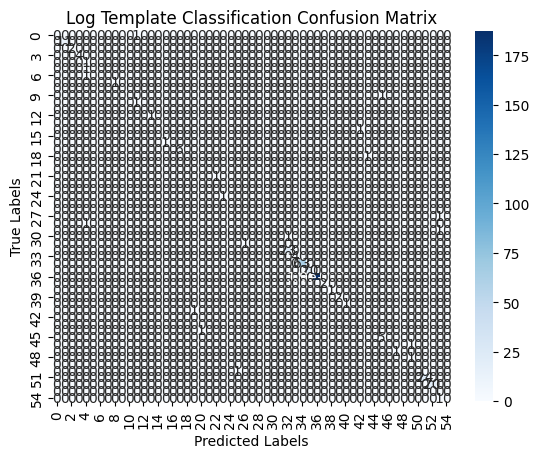

In [48]:
cm=confusion_matrix(y_test,pred_classes)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Log Template Classification Confusion Matrix')
plt.show()

In [49]:
errors=(y_test!=pred_classes)
import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# label_encoder=LabelEncoder()
output=pd.DataFrame({
    'actual':scaler.inverse_transform(y_test[errors]),
    'predicted':scaler.inverse_transform(pred_classes[errors])
})

output

,actual,predicted
0,audit: initializing netlink socket (disabled),There is already a security framework initiali...
1,"DMA zone: <*> pages, LIFO batch:<*>",Dentry cache hash table entries: <*> (order: <...
2,ACPI disabled because your bios is from <*> an...,Dentry cache hash table entries: <*> (order: <...
3,sdpd startup succeeded,Real Time Clock Driver v<*>.<*>
4,mapped 4G/4G trampoline to <*>.,NET: Registered protocol family <*>
5,Transparent bridge - <*>,usbcore: registered new driver hub
6,User unknown timed out after <*> seconds at <*...,BIOS-e820: <*> - <*> (reserved)
7,Enabling fast FPU save and restore... done.,Enabling unmasked SIMD FPU exception support.....
8,Couldn't authenticate user,notify question section contains no SOA
9,rpc.idmapd startup succeeded,rpc.statd startup succeeded


In [50]:
output.shape

(23, 2)